In [3]:
from zipfile import ZipFile

with ZipFile('/content/northstar_dataset.zip', 'r') as zip:
    zip.extractall('/content/northstar_data')

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [4]:
import os

os.listdir('/content/northstar_data')

['northstar_dataset']

In [5]:
os.listdir('/content/northstar_data/northstar_dataset')

['README.txt',
 'data_dictionary.csv',
 'drivers.csv',
 'incidents.csv',
 'customers.csv',
 'orders.csv',
 'complaints.csv',
 'deliveries.csv',
 'hubs.csv',
 'vehicles.csv',
 'app_events.csv']

In [6]:
import pandas as pd

deliveries = pd.read_csv('/content/northstar_data/northstar_dataset/deliveries.csv')

deliveries.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22


In [7]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   delivery_id                    950 non-null    object 
 1   order_id                       950 non-null    object 
 2   driver_id                      950 non-null    object 
 3   vehicle_id                     950 non-null    object 
 4   hub_id                         950 non-null    object 
 5   dispatch_time                  950 non-null    object 
 6   delivery_completed_at          931 non-null    object 
 7   delivery_status                950 non-null    object 
 8   route_distance_km              950 non-null    float64
 9   manual_route_override_count    950 non-null    int64  
 10  proof_of_completion_missing    950 non-null    int64  
 11  customer_rating_post_delivery  936 non-null    float64
 12  fuel_or_charge_cost            950 non-null    flo

In [8]:
deliveries.columns

Index(['delivery_id', 'order_id', 'driver_id', 'vehicle_id', 'hub_id',
       'dispatch_time', 'delivery_completed_at', 'delivery_status',
       'route_distance_km', 'manual_route_override_count',
       'proof_of_completion_missing', 'customer_rating_post_delivery',
       'fuel_or_charge_cost'],
      dtype='object')

In [9]:
deliveries.isnull().sum()

,0
delivery_id,0
order_id,0
driver_id,0
vehicle_id,0
hub_id,0
dispatch_time,0
delivery_completed_at,19
delivery_status,0
route_distance_km,0
manual_route_override_count,0


In [10]:
deliveries.describe()

,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
count,950.000000,950.000000,950.000000,936.000000,950.000000
mean,13.909316,0.969474,0.072632,3.864679,12.841295
std,7.477907,1.093189,0.259667,0.894420,4.336468
min,1.200000,0.000000,0.000000,1.000000,2.500000
25%,9.135000,0.000000,0.000000,3.360000,9.925000
50%,12.840000,1.000000,0.000000,4.040000,12.645000
75%,16.835000,2.000000,0.000000,4.550000,15.697500
max,41.940000,7.000000,1.000000,5.000000,29.430000


In [11]:
deliveries['delivery_status'].value_counts()

,count
delivery_status,
OnTime,616
Delayed,202
Failed,132


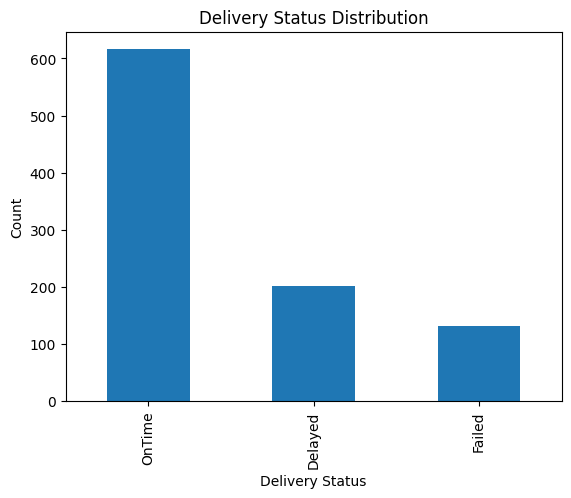

In [12]:
import matplotlib.pyplot as plt

deliveries['delivery_status'].value_counts().plot(kind='bar')

plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Count")

plt.show()

## Business Insight

The analysis of delivery statuses shows operational inefficiencies within the logistics process. A noticeable number of delayed and failed deliveries indicates potential issues in route planning, dispatch coordination, traffic management, or vehicle allocation. These operational failures may contribute directly to increased customer complaints and reduced service reliability.

In [13]:
deliveries.columns

Index(['delivery_id', 'order_id', 'driver_id', 'vehicle_id', 'hub_id',
       'dispatch_time', 'delivery_completed_at', 'delivery_status',
       'route_distance_km', 'manual_route_override_count',
       'proof_of_completion_missing', 'customer_rating_post_delivery',
       'fuel_or_charge_cost'],
      dtype='object')

In [14]:
deliveries['delivery_status'].value_counts()

,count
delivery_status,
OnTime,616
Delayed,202
Failed,132


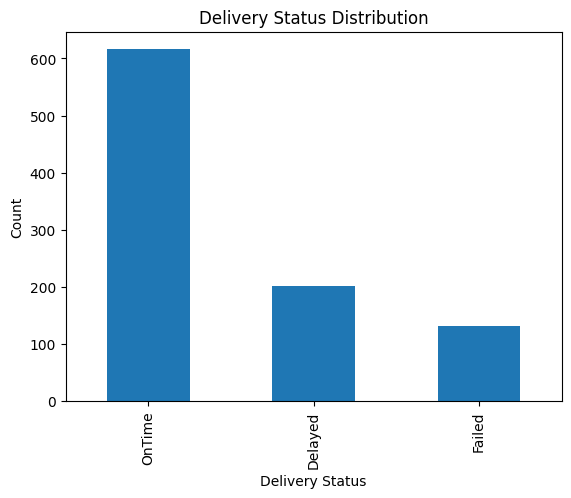

In [15]:
import matplotlib.pyplot as plt

deliveries['delivery_status'].value_counts().plot(kind='bar')

plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Count")

plt.show()

In [16]:
deliveries['customer_rating_post_delivery'].describe()

,customer_rating_post_delivery
count,936.000000
mean,3.864679
std,0.894420
min,1.000000
25%,3.360000
50%,4.040000
75%,4.550000
max,5.000000


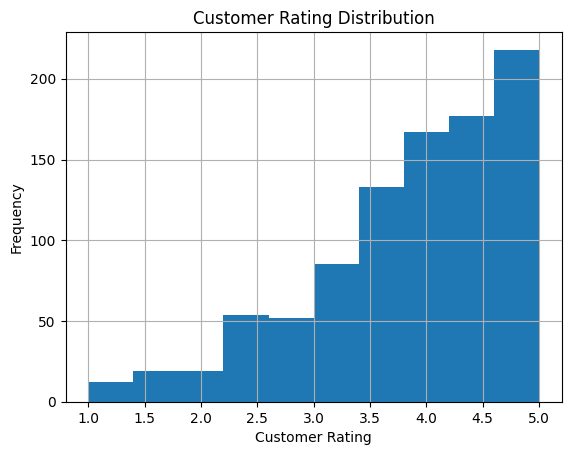

In [17]:
deliveries['customer_rating_post_delivery'].hist()

plt.title("Customer Rating Distribution")
plt.xlabel("Customer Rating")
plt.ylabel("Frequency")

plt.show()

## Customer Satisfaction Insight

The customer rating analysis indicates variations in delivery service quality. Lower customer ratings may be associated with delayed deliveries, route inefficiencies, or failed proof-of-completion records. This suggests that operational problems are directly affecting customer satisfaction and overall service reliability.

In [18]:
deliveries['manual_route_override_count'].describe()

,manual_route_override_count
count,950.000000
mean,0.969474
std,1.093189
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,7.000000


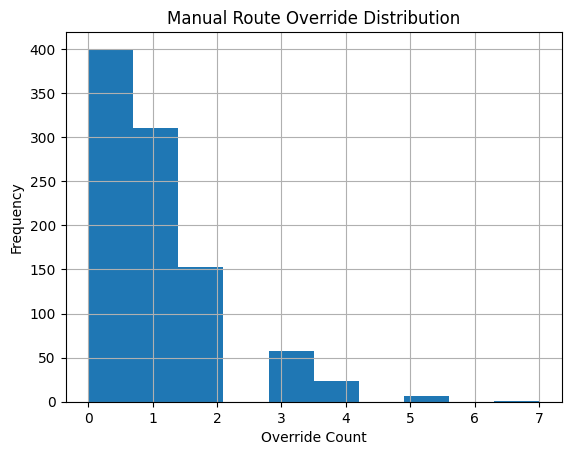

In [19]:
deliveries['manual_route_override_count'].hist()

plt.title("Manual Route Override Distribution")
plt.xlabel("Override Count")
plt.ylabel("Frequency")

plt.show()

## Route Override Insight

The analysis shows that some deliveries involve multiple manual route overrides. This may indicate poor route optimisation, traffic disruptions, inaccurate route planning, or operational inefficiencies. Excessive route overrides can increase delivery delays, fuel costs, and customer dissatisfaction.